# 03 — ABP y ABF in 1D

This notebooks studies the double-well potential as a first approximation to the use of Adaptive Biasing Potential and Adaptive Biasing Force

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid

from stage_escape.abp_abf import (
    ABFRealTime,
    ABPMetaDynamics,
    Potential,
    theoretical_density_1d,
    weighted_histogram_density,
)
from stage_escape.result_io import load_result, save_result

plt.rcParams.update(
    {
        "figure.figsize": (8.2, 4.9),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": False,
    }
)

QUICK_MODE = False
SAVE_RESULTS = False
SAVE_FIGURES = True

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró pyproject.toml. Ejecuta el notebook dentro del repositorio."
    )

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "notebook_03"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, name: str) -> None:
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{name}.png", bbox_inches="tight")
        fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.show()

## 1. Double-well potential

We use

$[
V(x)=(x^2-1)^2,
\qquad
V'(x)=4x(x^2-1).
]$

In [18]:
def double_well_value(position: np.ndarray) -> float:
    x = float(np.asarray(position, dtype=float)[0])
    return (x**2 - 1.0) ** 2

def double_well_gradient(position: np.ndarray) -> np.ndarray:
    x = float(np.asarray(position, dtype=float)[0])
    return np.array([4 * x * (x**2 - 1.0)], dtype=float)

def double_well_hessian(position: np.ndarray) -> np.ndarray:
    x = float(np.asarray(position, dtype=float)[0])
    return np.array([[12 * x**2 - 4]], dtype=float)

potential = Potential(
    dimension=1,
    function=double_well_value,
    first_derivative=double_well_gradient,
    second_derivative=double_well_hessian,
)

D = 0.10
DELTA_T = 1.0e-3
SEED = 2026
VALUE_RANGE = (-2.2, 2.2)

x_grid = np.linspace(*VALUE_RANGE, 1_000)
potential_values = np.array(
    [potential.potential_at(np.array([x])) for x in x_grid]
)
theoretical_density = theoretical_density_1d(potential, x_grid, D)

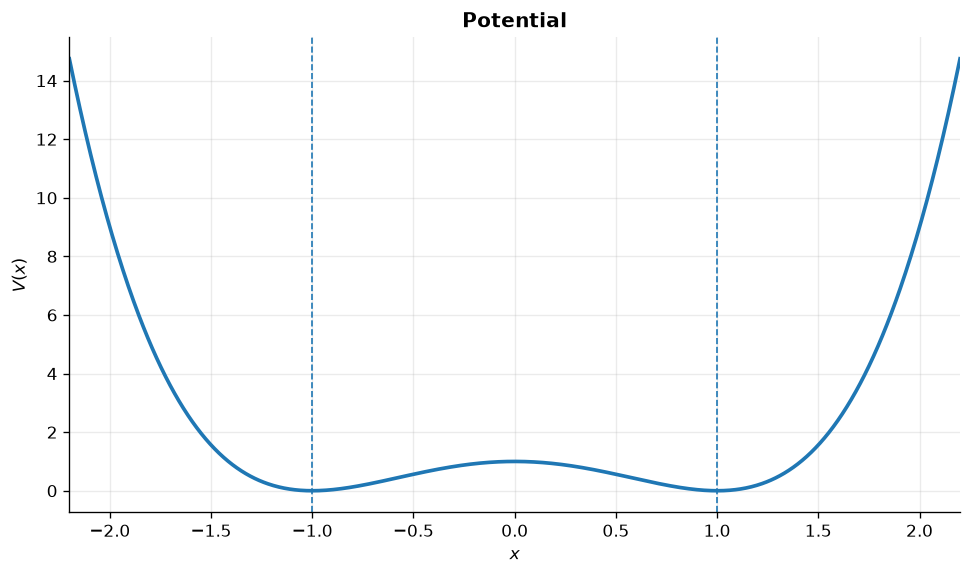

In [19]:
fig, ax = plt.subplots()
ax.plot(x_grid, potential_values, linewidth=2.2)
ax.axvline(-1.0, linestyle="--", linewidth=1.0)
ax.axvline(1.0, linestyle="--", linewidth=1.0)
ax.set(
    title="Potential",
    xlabel=r"$x$",
    ylabel=r"$V(x)$",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "double_well_potential")

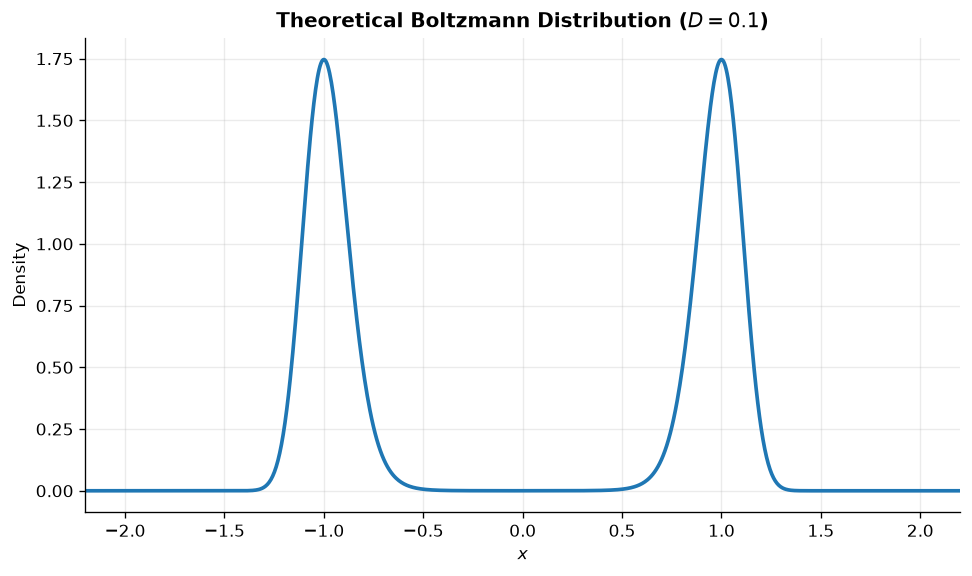

In [20]:
fig, ax = plt.subplots()
ax.plot(x_grid, theoretical_density, linewidth=2.2)
ax.set(
    title=rf"Theoretical Boltzmann Distribution ($D={D:g}$)",
    xlabel=r"$x$",
    ylabel="Density",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "double_well_theoretical_density")

## 2. ABP Metadynamics

In [21]:
ABP_STEPS = 40_000 if QUICK_MODE else 200_000

abp_simulation = ABPMetaDynamics(
    deposition_stride=100,
    transition_detector=None,
    delta_t=DELTA_T,
    dimension=1,
    D=D,
    initial_position=np.array([-1.0]),
    b=potential,
    W=0.01,
    sigma=0.15,
    seed=SEED,
)
abp_result = abp_simulation.run(max_steps=ABP_STEPS)

assert abp_result.n_steps == ABP_STEPS
assert len(abp_result.weights) == len(abp_result.positions)

print("termination       :", abp_result.termination_reason)
print("steps             :", abp_result.n_steps)
print("centers deposited :", len(abp_result.centers))
print("physical time      :", f"{abp_result.physical_time:.6g}")

if SAVE_RESULTS:
    save_result(abp_result, RESULT_DIR / "abp_double_well")

termination       : max_steps
steps             : 200000
centers deposited : 2000
physical time      : 2.0764e+13


### Trajectory and bias

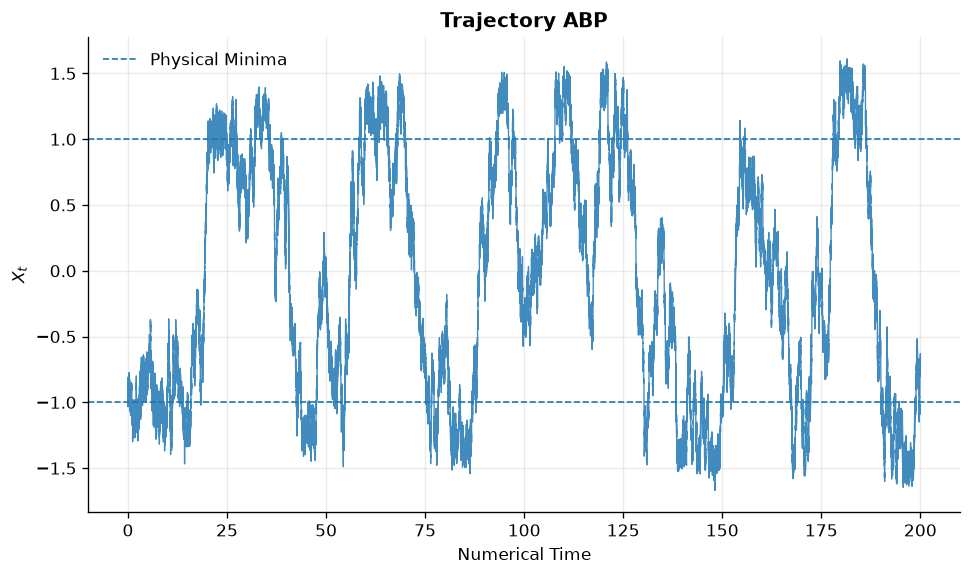

In [22]:
abp_positions = abp_result.positions[:, 0]
abp_time = np.arange(len(abp_positions)) * abp_result.delta_t

fig, ax = plt.subplots()
ax.plot(abp_time, abp_positions, linewidth=0.8, alpha=0.85)
ax.axhline(-1.0, linestyle="--", linewidth=1.0, label="Physical Minima")
ax.axhline(1.0, linestyle="--", linewidth=1.0)
ax.set(
    title="Trajectory ABP",
    xlabel="Numerical Time",
    ylabel=r"$X_t$",
)
ax.legend()
finish_figure(fig, "abp_trajectory")

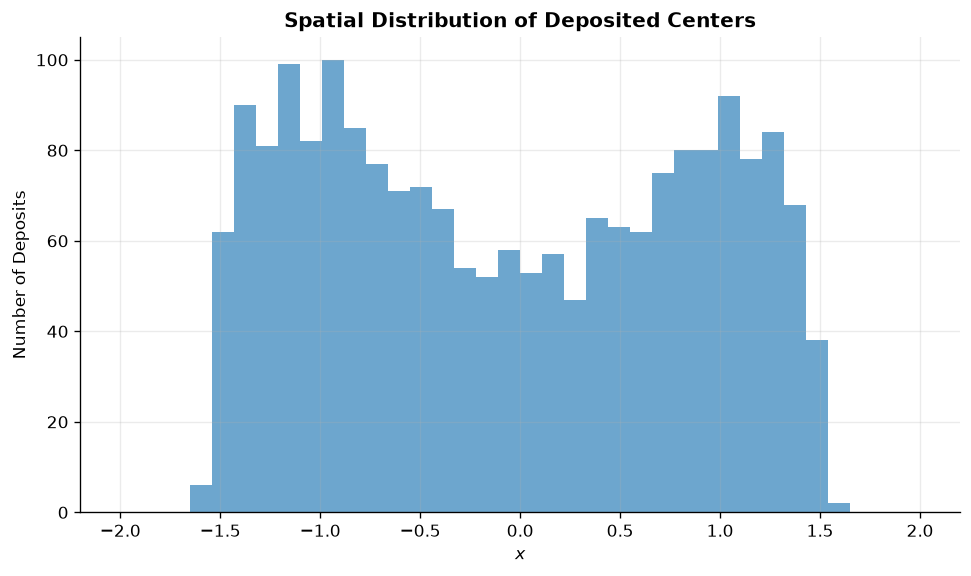

In [23]:
fig, ax = plt.subplots()
ax.hist(
    abp_result.centers[:, 0],
    bins=40,
    range=VALUE_RANGE,
    alpha=0.65,
)
ax.set(
    title="Spatial Distribution of Deposited Centers",
    xlabel=r"$x$",
    ylabel="Number of Deposits",
    xlim=VALUE_RANGE,
)
finish_figure(fig, "abp_deposition_centers")

### Effective Potential

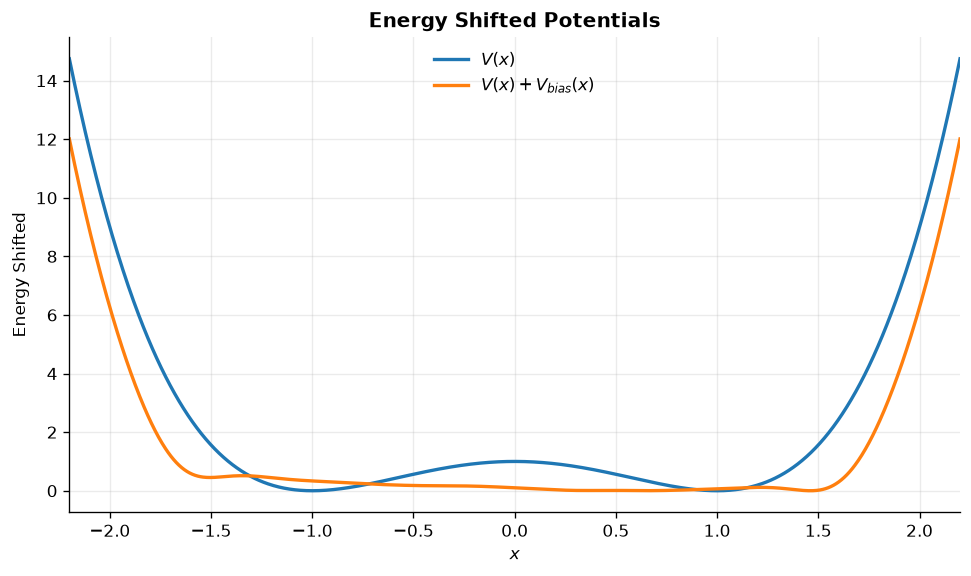

In [24]:
bias_values = np.array(
    [abp_simulation.bias_potential_at(np.array([x])) for x in x_grid]
)
effective_values = potential_values + bias_values

physical_shifted = potential_values - potential_values.min()
effective_shifted = effective_values - effective_values.min()

fig, ax = plt.subplots()
ax.plot(x_grid, physical_shifted, linewidth=2.0, label=r"$V(x)$")
ax.plot(
    x_grid,
    effective_shifted,
    linewidth=2.0,
    label=r"$V(x)+V_{bias}(x)$",
)
ax.set(
    title="Energy Shifted Potentials",
    xlabel=r"$x$",
    ylabel="Energy Shifted",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abp_effective_potential")

### Bias distribution and Reweighted Distribution

The ABP trajectory does not directly follow the physical distribution. The weights stored in ABPResult allow it to be reconstructed.

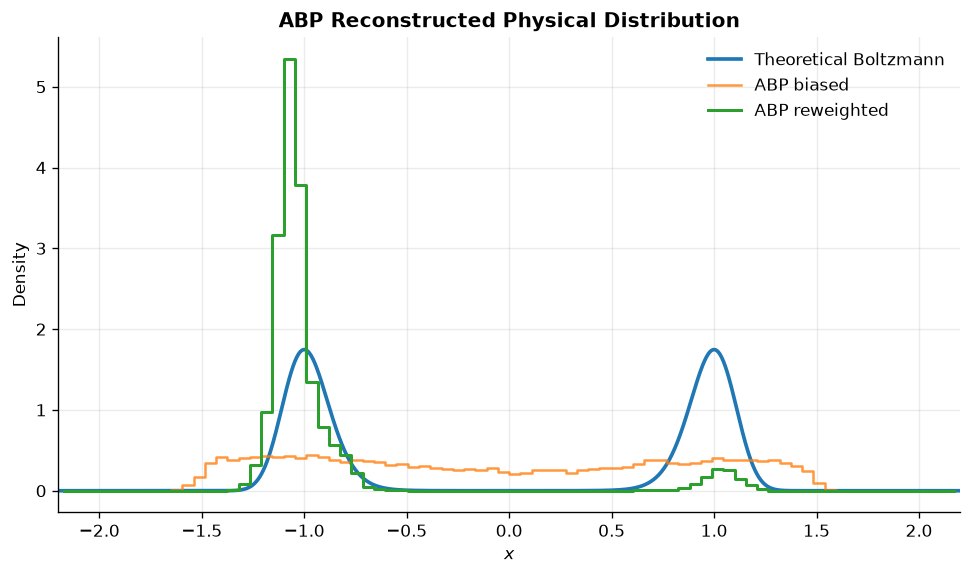

Distancia L1 sin reponderar : 1.20908
Distancia L1 reponderada    : 1.01469


In [25]:
histogram_kwargs = {
    "bins": 80,
    "value_range": VALUE_RANGE,
}

bin_centers, biased_density, _, bin_edges = weighted_histogram_density(
    values=abp_positions,
    weights=None,
    **histogram_kwargs,
)
weighted_centers, reweighted_density, _, _ = weighted_histogram_density(
    values=abp_positions,
    weights=abp_result.weights,
    **histogram_kwargs,
)
np.testing.assert_allclose(bin_centers, weighted_centers)

theory_on_bins = np.interp(bin_centers, x_grid, theoretical_density)
l1_biased = trapezoid(np.abs(biased_density - theory_on_bins), bin_centers)
l1_reweighted = trapezoid(
    np.abs(reweighted_density - theory_on_bins),
    bin_centers,
)

fig, ax = plt.subplots()
ax.plot(
    x_grid,
    theoretical_density,
    linewidth=2.2,
    label="Theoretical Boltzmann",
)
ax.step(
    bin_centers,
    biased_density,
    where="mid",
    alpha=0.8,
    label="ABP biased",
)
ax.step(
    bin_centers,
    reweighted_density,
    where="mid",
    linewidth=1.8,
    label="ABP reweighted",
)
ax.set(
    title="ABP Reconstructed Physical Distribution",
    xlabel=r"$x$",
    ylabel="Density",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abp_reweighted_density")

print(f"Distancia L1 sin reponderar : {l1_biased:.5f}")
print(f"Distancia L1 reponderada    : {l1_reweighted:.5f}")

In [26]:
weights = np.asarray(abp_result.weights, dtype=float)
effective_sample_size = weights.sum() ** 2 / np.dot(weights, weights)
effective_fraction = effective_sample_size / len(weights)

print(f"Sample Size       : {len(weights):,}")
print(f"Effective Sample Size    : {effective_sample_size:,.1f}")
print(f"Effective Sample Fraction  : {effective_fraction:.2%}")

Sample Size       : 200,001
Effective Sample Size    : 2,229.6
Effective Sample Fraction  : 1.11%


## 3. ABF in real time

In [27]:
ABF_STEPS = 60_000 if QUICK_MODE else 300_000

abf_simulation = ABFRealTime(
    transition_detector=None,
    delta_t=DELTA_T,
    D=D,
    initial_position=np.array([-1.0]),
    b=potential,
    bins=100,
    value_range=VALUE_RANGE,
    seed=SEED + 1,
    profile_update_stride=25,
    out_of_range="clip",
)
abf_result = abf_simulation.run(max_steps=ABF_STEPS)

assert abf_result.n_steps == ABF_STEPS
assert int(abf_result.visit_counts.sum()) == ABF_STEPS

print("termination  :", abf_result.termination_reason)
print("steps        :", abf_result.n_steps)
print("physical time:", f"{abf_result.physical_time:.6g}")

if SAVE_RESULTS:
    save_result(abf_result, RESULT_DIR / "abf_double_well")

termination  : max_steps
steps        : 300000
physical time: 3.92988e+62


### Potential Derivative Estimation

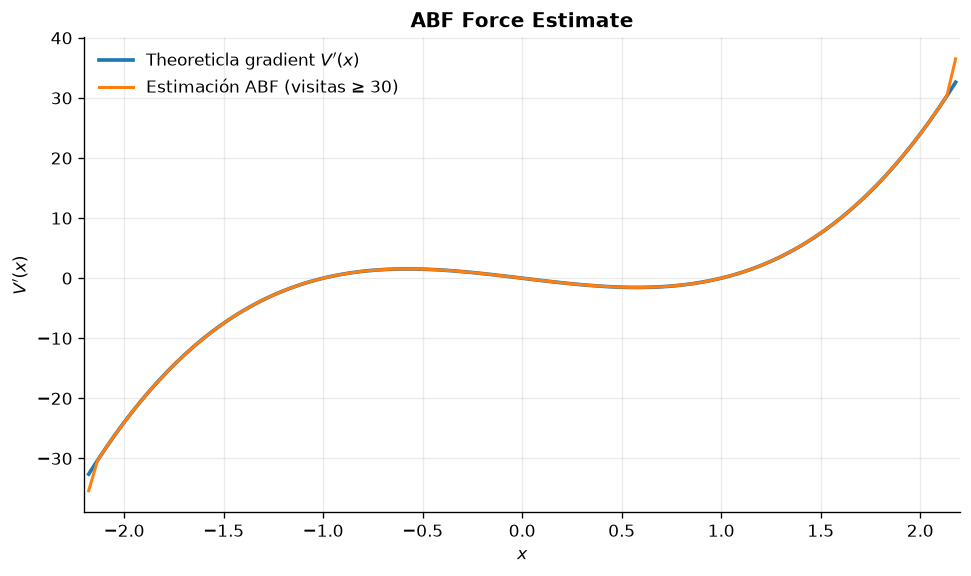

In [28]:
abf_bin_centers = 0.5 * (
    abf_result.bin_edges[:-1] + abf_result.bin_edges[1:]
)
true_gradient = np.array(
    [double_well_gradient(np.array([x]))[0] for x in abf_bin_centers]
)

MIN_VISITS = 30
sufficiently_visited = abf_result.visit_counts >= MIN_VISITS

fig, ax = plt.subplots()
ax.plot(
    abf_bin_centers,
    true_gradient,
    linewidth=2.2,
    label=r"Theoreticla gradient $V'(x)$",
)
ax.plot(
    abf_bin_centers[sufficiently_visited],
    abf_result.force_bias[sufficiently_visited],
    linewidth=1.8,
    label=rf"Estimación ABF (visitas ≥ {MIN_VISITS})",
)
ax.set(
    title="ABF Force Estimate",
    xlabel=r"$x$",
    ylabel=r"$V'(x)$",
    xlim=VALUE_RANGE,
)
ax.legend()
finish_figure(fig, "abf_force_estimate")

### Free Energy

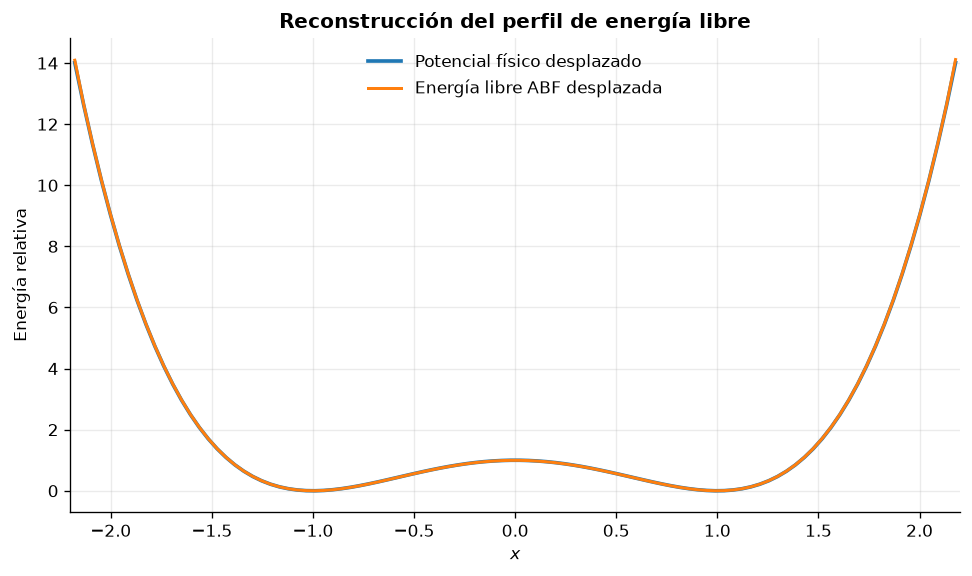

In [29]:
physical_on_bins = np.array(
    [double_well_value(np.array([x])) for x in abf_bin_centers]
)

if np.any(sufficiently_visited):
    estimated_free_energy = abf_result.free_energy.copy()
    estimated_free_energy -= estimated_free_energy[sufficiently_visited].min()

    physical_reference = physical_on_bins.copy()
    physical_reference -= physical_reference[sufficiently_visited].min()

    fig, ax = plt.subplots()
    ax.plot(
        abf_bin_centers[sufficiently_visited],
        physical_reference[sufficiently_visited],
        linewidth=2.2,
        label="Potencial físico desplazado",
    )
    ax.plot(
        abf_bin_centers[sufficiently_visited],
        estimated_free_energy[sufficiently_visited],
        linewidth=1.8,
        label="Energía libre ABF desplazada",
    )
    ax.set(
        title="Reconstrucción del perfil de energía libre",
        xlabel=r"$x$",
        ylabel="Energía relativa",
        xlim=VALUE_RANGE,
    )
    ax.legend()
    finish_figure(fig, "abf_free_energy")
else:
    print(
        "No hay bins con suficientes visitas. "
        "Aumenta ABF_STEPS o reduce MIN_VISITS."
    )